# 1.6 G0 Elastic Reference

This notebook builds the first clean **G0 elastic reference** on the 500-block pilot window.

The workflow is:

$$
H0_{\text{observed}}
\xrightarrow{\text{behavioral priors}}
G0_{\text{Glamsterdam counterfactual}}
\xrightarrow{\text{equilibrium solve}}
\text{G0-local resource shares and elasticities}
$$

In words:

- start from observed H0 quantities and prices;
- reprice the same historical activity under EIP-8037, EIP-7976, and EIP-7981;
- solve a counterfactual G0 equilibrium using H0 behavioral priors;
- recover G0-local implied elasticities for later A/B simulations.

The important distinction is that **G0 is not observed data**. We do not estimate
new elasticities from G0. We transport the H0/Maria/EIP-7623 behavioral priors
into G0, recompute G0 shares, and then recover G0-local implied elasticities.


## Design Choices

This G0 model splits demand into three resources:

$$
\mathcal{R}_{G0}
= \{\text{execution},\ \text{data},\ \text{state}\}
$$

G0 itself still has one shared base-fee path:

$$
u^{\text{base-fee}}_{G0}
= \max\left(g_{\text{regular}},\ g_{\text{state}}\right)
$$

where:

$$
g_{\text{regular}}
= g_{\text{execution}} + g_{\text{data folded into regular}}
$$

For this notebook:

- state is EIP-8037 state gas;
- data is calldata floor repricing plus EIP-7981 access-list data surcharge;
- execution is the remaining G0 regular gas;
- BAL bytes are **not priced in G0** and do **not** consume G0 gas here.

BALs become priced in Mechanism A/B when bandwidth becomes a separate EIP-7999 resource.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from basefee.eip1559 import update_eip1559_base_fee
from demand import (
    Anchor,
    DemandParams,
    FeeDimension,
    WorldSpec,
    anchor_from_equilibrium,
    implied_anchor_elasticities,
    solve_equilibrium,
)

pd.options.display.float_format = "{:,.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

START_BLOCK = 24_120_001
END_BLOCK = 24_120_500
BLOCK_LABEL = f"{START_BLOCK}_{END_BLOCK}"

G0_REPRICING_CSV = DATA_DIR / f"glamsterdam_regular_gas_recalculation_{BLOCK_LABEL}.csv"
FULL_7999_REPLAY_CSV = DATA_DIR / f"full_7999_replay_{BLOCK_LABEL}.csv"
EIP7623_ELASTICITY_CSV = DATA_DIR / "eip7623_event_implied_elasticity_sweep_2025-03-07_2025-07-08.csv"

OUT_DECOMP_CSV = DATA_DIR / f"g0_reference_decomposition_{BLOCK_LABEL}.csv"
OUT_RESULTS_CSV = DATA_DIR / f"g0_elastic_reference_results_{BLOCK_LABEL}.csv"
OUT_SWEEP_CSV = DATA_DIR / f"g0_eta_data_sweep_{BLOCK_LABEL}.csv"
OUT_ELASTIC_REPLAY_CSV = DATA_DIR / f"g0_elastic_replay_diagnostic_{BLOCK_LABEL}.csv"
OUT_BASEFEE_MODEL_CSV = DATA_DIR / f"g0_equilibrium_base_fee_model_{BLOCK_LABEL}.csv"

SHARE_MODE = "maria_own_price"

## Load The 500-Block Inputs

The 500-block pilot window already has transaction-level G0 regular-gas repricing from notebook `0.6` and passive G0 replay from notebook `0.7`.

We also merge the current EIP-7623 calldata de-accounting from the full-7999 replay file, because H0 data should include the current calldata floor uplift. That avoids hiding current data gas inside execution.

In [2]:
g0_raw = pd.read_csv(G0_REPRICING_CSV)
current_data = pd.read_csv(FULL_7999_REPLAY_CSV)[[
    "block_number",
    "standard_calldata_gas_current",
    "current_7623_floor_uplift_observed",
    "current_calldata_deaccounted_gas",
    "bal_rlp_bytes",
]]

blocks = g0_raw.merge(current_data, on="block_number", how="inner", validate="one_to_one")

assert len(blocks) == 500
assert (blocks["standard_calldata_gas"] == blocks["standard_calldata_gas_current"]).all()

blocks[["block_number", "timestamp", "current_gas_used_from_txs", "regular_gas_glamsterdam", "state_gas_8037"]].head()

,block_number,timestamp,current_gas_used_from_txs,regular_gas_glamsterdam,state_gas_8037
0,24120001,2025-12-29 18:10:35,59964904,54038829,42310620
1,24120002,2025-12-29 18:10:47,13753679,11765253,13693500
2,24120003,2025-12-29 18:10:59,41015898,34135767,43098570
3,24120004,2025-12-29 18:11:11,23756933,19321970,31432320
4,24120005,2025-12-29 18:11:23,16941785,15323901,13558860


## Decompose H0 And Passive G0

H0 is the observed current world. The three H0 physical quantities are measured in current-rule gas units:

$$
\text{state}_{H0}
= \text{historical current-rule state creation gas}
$$

$$
\text{data}_{H0}
= \text{standard calldata gas} + \text{current EIP-7623 floor uplift}
$$

$$
\text{execution}_{H0}
= \text{current gas used} - \text{state}_{H0} - \text{data}_{H0}
$$

Passive G0 maps the same historical activity into Glamsterdam metered gas:

$$
\text{state}_{G0}
= \text{EIP-8037 state gas}
$$

$$
\text{data}_{G0}
= \text{standard calldata gas}
+ \text{EIP-7976 floor uplift}
+ \text{EIP-7981 access-list data cost}
$$

$$
\text{execution}_{G0}
= \text{regular gas}_{G0} - \text{data}_{G0}
$$

No BAL term appears in these G0 gas equations.

In [3]:
# H0 observed components.
blocks["h0_state_gas"] = blocks["historical_state_creation_gas_total"]
blocks["h0_data_gas"] = blocks["current_calldata_deaccounted_gas"]
blocks["h0_execution_gas"] = (
    blocks["current_gas_used_from_txs"]
    - blocks["h0_state_gas"]
    - blocks["h0_data_gas"]
)

# Passive G0 metered components. BAL is deliberately excluded.
blocks["g0_state_gas"] = blocks["state_gas_8037"]
blocks["g0_data_gas"] = (
    blocks["standard_calldata_gas"]
    + blocks["glamsterdam_7976_floor_uplift"]
    + blocks["access_list_data_cost_7981"]
)
blocks["g0_execution_gas"] = blocks["regular_gas_glamsterdam"] - blocks["g0_data_gas"]
blocks["g0_regular_gas"] = blocks["g0_execution_gas"] + blocks["g0_data_gas"]
blocks["g0_max_regular_state_gas"] = blocks[["g0_regular_gas", "g0_state_gas"]].max(axis=1)
blocks["g0_bottleneck"] = np.where(
    blocks["g0_regular_gas"] >= blocks["g0_state_gas"],
    "regular",
    "state",
)

for col in ["h0_execution_gas", "h0_data_gas", "h0_state_gas", "g0_execution_gas", "g0_data_gas", "g0_state_gas"]:
    if (blocks[col] < 0).any():
        raise ValueError(f"negative values in {col}")

blocks.to_csv(OUT_DECOMP_CSV, index=False)

summary = pd.DataFrame([
    {
        "world": "H0_observed",
        "execution_gas_M": blocks["h0_execution_gas"].mean() / 1e6,
        "data_gas_M": blocks["h0_data_gas"].mean() / 1e6,
        "state_gas_M": blocks["h0_state_gas"].mean() / 1e6,
        "regular_gas_M": (blocks["h0_execution_gas"] + blocks["h0_data_gas"]).mean() / 1e6,
        "max_regular_state_gas_M": blocks["current_gas_used_from_txs"].mean() / 1e6,
    },
    {
        "world": "G0_passive_repriced",
        "execution_gas_M": blocks["g0_execution_gas"].mean() / 1e6,
        "data_gas_M": blocks["g0_data_gas"].mean() / 1e6,
        "state_gas_M": blocks["g0_state_gas"].mean() / 1e6,
        "regular_gas_M": blocks["g0_regular_gas"].mean() / 1e6,
        "max_regular_state_gas_M": blocks["g0_max_regular_state_gas"].mean() / 1e6,
    },
])
summary

,world,execution_gas_M,data_gas_M,state_gas_M,regular_gas_M,max_regular_state_gas_M
0,H0_observed,24.462873,1.072056,4.935713,25.534929,30.470642
1,G0_passive_repriced,25.042216,2.042926,28.665593,27.085142,33.316308


In [4]:
h0_totals = {
    "execution": float(blocks["h0_execution_gas"].sum()),
    "data": float(blocks["h0_data_gas"].sum()),
    "state": float(blocks["h0_state_gas"].sum()),
}

g0_totals = {
    "execution": float(blocks["g0_execution_gas"].sum()),
    "data": float(blocks["g0_data_gas"].sum()),
    "state": float(blocks["g0_state_gas"].sum()),
}

multipliers = {name: g0_totals[name] / h0_totals[name] for name in h0_totals}
shares_h0 = {name: h0_totals[name] / sum(h0_totals.values()) for name in h0_totals}
shares_g0_passive_physical = {
    name: h0_totals[name] / sum(h0_totals.values()) for name in h0_totals
}
shares_g0_passive_metered = {name: g0_totals[name] / sum(g0_totals.values()) for name in g0_totals}

multiplier_table = pd.DataFrame([
    {
        "resource": name,
        "h0_mean_gas_M": h0_totals[name] / len(blocks) / 1e6,
        "g0_passive_metered_mean_gas_M": g0_totals[name] / len(blocks) / 1e6,
        "g0_metering_multiplier": multipliers[name],
        "h0_physical_share": shares_h0[name],
        "g0_passive_metered_share": shares_g0_passive_metered[name],
    }
    for name in ["execution", "data", "state"]
])
multiplier_table

,resource,h0_mean_gas_M,g0_passive_metered_mean_gas_M,g0_metering_multiplier,h0_physical_share,g0_passive_metered_share
0,execution,24.462873,25.042216,1.023683,0.802834,0.449182
1,data,1.072056,2.042926,1.905615,0.035183,0.036644
2,state,4.935713,28.665593,5.807792,0.161983,0.514174


## H0 Behavioral Priors

We use:

$$
\epsilon_{\text{agg}} = 0.175
$$

from Maria's gas-limit-increase event estimate, and:

$$
\eta_{\text{state}} = 0.43
$$

from Maria's long-run state-share estimate.

For the data-vs-execution split, we use the state-cleaned EIP-7623 event-study estimate:

$$
\eta_{\text{data}} = 0.429418
$$

This is a calldata-vs-execution prior. It is useful for G0 because G0 includes EIP-7976 and EIP-7981, which reprice data-like activity inside regular gas.

In [5]:
EPS_AGG = 0.175
ETA_STATE_CENTRAL = 0.43

eta_sweep = pd.read_csv(EIP7623_ELASTICITY_CSV)
ETA_DATA_CENTRAL = float(
    eta_sweep.loc[
        eta_sweep["interpretation"].eq("state-cleaned long-window effective eta"),
        "eta_data",
    ].iloc[0]
)
ETA_DATA_VALUES = [0.0, 0.1, 0.3, ETA_DATA_CENTRAL, 0.6, 1.0]

print("ETA_DATA_CENTRAL", ETA_DATA_CENTRAL)
eta_sweep[["eta_data", "epsilon_data", "epsilon_execution", "interpretation"]]

ETA_DATA_CENTRAL 0.4294175530575123


,eta_data,epsilon_data,epsilon_execution,interpretation
0,0.000000,0.080000,0.080000,fixed data/execution split
1,0.100000,0.174751,0.074751,sensitivity
2,0.300000,0.364252,0.064252,sensitivity
3,0.430000,0.487428,0.057428,state-cleaned EIP-7623 central prior
4,0.600000,0.648504,0.048504,sensitivity
5,1.000000,1.027506,0.027506,aggressive short-run sensitivity
6,0.326236,0.389110,0.062875,main long-window effective eta
7,0.429418,0.486876,0.057458,state-cleaned long-window effective eta


## Solve The G0 Equilibrium

The central G0 scenario is a 100M `max(regular, state)` gas limit, which corresponds to a 50M EIP-1559 target.

We also include a 200M-limit sensitivity with a 100M target.

The world has one shared fee dimension:

$$
u_{G0}
= \max\left(
  m_{\text{execution}}q_{\text{execution}}
  + m_{\text{data}}q_{\text{data}},
  m_{\text{state}}q_{\text{state}}
\right)
$$

where:

- $q_r$ is physical H0-style demand for resource $r$ after the demand response;
- $m_r$ is the G0/H0 metering multiplier for resource $r$;
- $u_{G0}$ is the gas-use input that must equal the target at equilibrium, unless the model hits a floor.


In [6]:
base_fee_ref = float(blocks["base_fee_per_gas"].median())
h0_quantities = {
    "execution": float(blocks["h0_execution_gas"].mean()),
    "data": float(blocks["h0_data_gas"].mean()),
    "state": float(blocks["h0_state_gas"].mean()),
}

anchor_h0 = Anchor(
    quantities=h0_quantities,
    effective_prices={name: base_fee_ref for name in h0_quantities},
)

def recover_data_execution_elasticities(epsilon_rest: float, alpha_data_given_rest: float, eta_data: float) -> dict:
    epsilon_data = epsilon_rest + eta_data * (1.0 - alpha_data_given_rest)
    epsilon_execution = epsilon_rest - eta_data * alpha_data_given_rest
    return {
        "epsilon_data": epsilon_data,
        "epsilon_execution": epsilon_execution,
        "valid_nonnegative_execution": epsilon_execution >= 0,
    }

rows = []
for gas_limit in [100_000_000, 200_000_000]:
    target = gas_limit / 2
    world = WorldSpec(
        name=f"G0_glamsterdam_limit_{gas_limit}",
        multipliers=multipliers,
        dimensions=(
            FeeDimension(
                name="regular_state",
                groups=(("execution", "data"), ("state",)),
                target_gas=target,
            ),
        ),
    )
    for eta_data in ETA_DATA_VALUES:
        params = DemandParams(
            eps_agg=EPS_AGG,
            eta_state=ETA_STATE_CENTRAL,
            eta_data=eta_data,
            share_mode=SHARE_MODE,
        )
        eq = solve_equilibrium(anchor_h0, params, world)
        anchor_g0 = anchor_from_equilibrium(anchor_h0, world, eq)
        implied = implied_anchor_elasticities(anchor_g0, params)
        alpha_data_given_rest_g0 = anchor_g0.data_share_of_rest
        recovered = recover_data_execution_elasticities(
            epsilon_rest=implied["rest"],
            alpha_data_given_rest=alpha_data_given_rest_g0,
            eta_data=eta_data,
        )
        regular_metered = (
            eq.quantities["execution"] * multipliers["execution"]
            + eq.quantities["data"] * multipliers["data"]
        )
        state_metered = eq.quantities["state"] * multipliers["state"]
        rows.append({
            "gas_limit": gas_limit,
            "gas_target": target,
            "share_mode": SHARE_MODE,
            "eta_data": eta_data,
            "converged": eq.converged,
            "floor_binding": eq.floor_binding["regular_state"],
            "binding_group": "state" if eq.binding_group["regular_state"] == 1 else "regular",
            "base_fee_gwei": eq.prices_wei["regular_state"] / 1e9,
            "base_fee_ratio_to_h0_median": eq.prices_wei["regular_state"] / base_fee_ref,
            "price_index_ratio": eq.price_index_ratio,
            "demand_expansion_x": eq.demand_expansion,
            "execution_physical_gas_M": eq.quantities["execution"] / 1e6,
            "data_physical_gas_M": eq.quantities["data"] / 1e6,
            "state_physical_gas_M": eq.quantities["state"] / 1e6,
            "execution_metered_gas_M": eq.quantities["execution"] * multipliers["execution"] / 1e6,
            "data_metered_gas_M": eq.quantities["data"] * multipliers["data"] / 1e6,
            "state_metered_gas_M": state_metered / 1e6,
            "regular_metered_gas_M": regular_metered / 1e6,
            "g0_basefee_input_gas_M": max(regular_metered, state_metered) / 1e6,
            "alpha_state_G0_physical": anchor_g0.alpha_state,
            "alpha_data_given_rest_G0_physical": alpha_data_given_rest_g0,
            "epsilon_state_G0": implied["state"],
            "epsilon_rest_G0": implied["rest"],
            **recovered,
        })

results = pd.DataFrame(rows)
results.to_csv(OUT_RESULTS_CSV, index=False)

central = results[
    (results["gas_limit"] == 100_000_000)
    & np.isclose(results["eta_data"], ETA_DATA_CENTRAL)
].copy()
central

,gas_limit,gas_target,share_mode,eta_data,converged,floor_binding,binding_group,base_fee_gwei,base_fee_ratio_to_h0_median,price_index_ratio,...,state_metered_gas_M,regular_metered_gas_M,g0_basefee_input_gas_M,alpha_state_G0_physical,alpha_data_given_rest_G0_physical,epsilon_state_G0,epsilon_rest_G0,epsilon_data,epsilon_execution,valid_nonnegative_execution
3,100000000,"50,000,000.000000",maria_own_price,0.429418,True,False,state,0.006683,0.087850,0.160735,...,50.000000,35.093389,50.000000,0.205186,0.032470,0.516770,0.086770,0.502244,0.072827,True


## Central 100M-Limit Interpretation

The table below is the main 100M-limit G0 reference.

We use Maria's original own-price-style interpretation as the central model: state share responds to the resource's effective price after repricing. This is the closest match to the G0 mechanism because EIP-8037 changes state's effective gas cost while G0 still has one shared base-fee path over `max(regular, state)`.


In [7]:
central_display = central[[
    "share_mode",
    "binding_group",
    "base_fee_gwei",
    "base_fee_ratio_to_h0_median",
    "demand_expansion_x",
    "regular_metered_gas_M",
    "state_metered_gas_M",
    "g0_basefee_input_gas_M",
    "alpha_state_G0_physical",
    "alpha_data_given_rest_G0_physical",
    "epsilon_state_G0",
    "epsilon_rest_G0",
    "epsilon_data",
    "epsilon_execution",
]]
central_display

,share_mode,binding_group,base_fee_gwei,base_fee_ratio_to_h0_median,demand_expansion_x,regular_metered_gas_M,state_metered_gas_M,g0_basefee_input_gas_M,alpha_state_G0_physical,alpha_data_given_rest_G0_physical,epsilon_state_G0,epsilon_rest_G0,epsilon_data,epsilon_execution
3,maria_own_price,state,0.006683,0.087850,1.376989,35.093389,50.000000,50.000000,0.205186,0.032470,0.516770,0.086770,0.502244,0.072827


## Equilibrium Base-Fee Model

This plot mirrors Maria's gas-limit/base-fee visualization, but for the G0 counterfactual. The x-axis changes the shared `max(regular, state)` gas limit relative to the H0 60M-ish limit. The y-axis reports the solved G0 equilibrium base fee relative to the H0 median base fee.

There are two curves because they answer different questions.

The dashed reference line is the aggregate-only constant-elasticity benchmark:

$$
\frac{p(L)}{p_{H0}}
=
\left(\frac{L}{L_{H0}}\right)^{-1/\epsilon_{\text{agg}}}
$$

This is a one-resource benchmark. It asks: if the only change were a larger gas limit, and all gas were homogeneous, how much would the equilibrium base fee fall? It ignores state repricing, data repricing, and the `max(regular, state)` bottleneck.

The solid line is the full G0 solved equilibrium. G0 is not just “H0 with a larger gas limit”; it changes the metering system:

- state is repriced by EIP-8037;
- calldata-heavy transactions are affected by EIP-7976;
- access-list data is affected by EIP-7981;
- the shared base-fee input is the bottleneck between regular gas and state gas.

For a candidate G0 gas limit $L$, the target is:

$$
T_{G0} = \frac{L}{2}
$$

The G0 solver searches for the shared base fee $p$ such that demand lands on the target:

$$
u_{G0}(p) = T_{G0}
$$

where:

$$
u_{G0}(p)
=
\max\left(
  g_{\text{regular}}(p),
  g_{\text{state}}(p)
\right)
$$

and:

$$
g_{\text{regular}}(p)
=
  m_{\text{execution}}q_{\text{execution}}(p)
  + m_{\text{data}}q_{\text{data}}(p)
$$

$$
g_{\text{state}}(p)
=
  m_{\text{state}}q_{\text{state}}(p)
$$

Here $q_r(p)$ is the physical demand for resource $r$ after the demand response, and $m_r$ is the G0/H0 metering multiplier for that resource. The quantities come from the nested demand model: aggregate demand responds to the spend-weighted price index, state share responds using Maria's state-vs-rest elasticity, and data/execution share responds using $\eta_{\text{data}}$.

So the dashed curve says: “what if gas were one homogeneous resource?” The solid curve says: “after Glamsterdam reprices state and data differently, and after demand composition responds, what shared base fee clears the `max(regular, state)` target?”

That is why the G0 line can start below the aggregate benchmark even at the H0 gas limit. The G0 curve includes the counterfactual repricing itself, not only a pure gas-limit expansion. The markers show the 100M and 200M scenarios used elsewhere in the notebook.


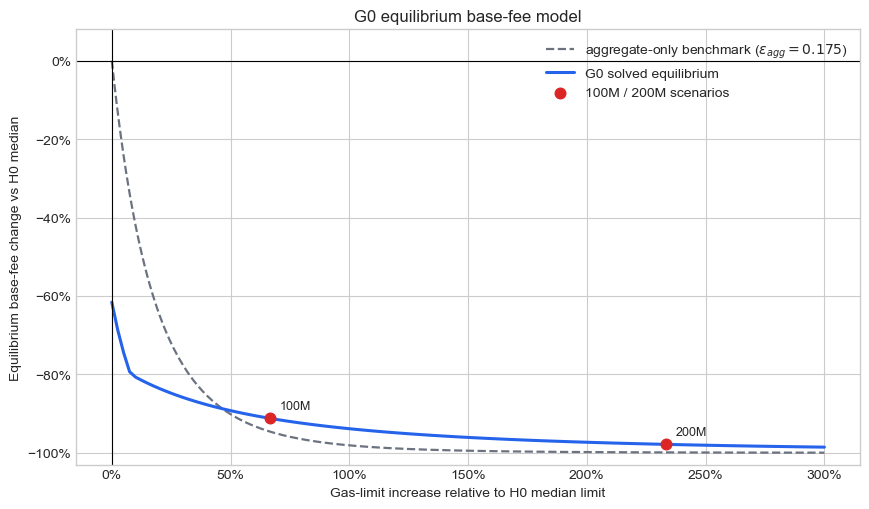

,gas_limit,gas_limit_increase_pct,base_fee_gwei,base_fee_ratio_to_h0_median,demand_expansion_x,g0_basefee_input_gas_M,binding_group
0,"60,000,000.000000",0.000000,0.029219,0.384072,1.063685,30.000000,regular
27,"100,000,000.000000",0.666667,0.006683,0.087850,1.376989,50.000000,state
95,"200,000,000.000000",2.333333,0.001639,0.021540,1.761030,100.000000,state


In [8]:
from matplotlib.ticker import PercentFormatter

h0_reference_gas_limit = float(blocks["gas_limit"].median())
central_params = DemandParams(
    eps_agg=EPS_AGG,
    eta_state=ETA_STATE_CENTRAL,
    eta_data=ETA_DATA_CENTRAL,
    share_mode=SHARE_MODE,
)

gas_limit_grid = np.unique(np.concatenate([
    np.linspace(h0_reference_gas_limit, 240_000_000, 121),
    np.array([100_000_000, 200_000_000], dtype=float),
]))
curve_rows = []
for gas_limit in gas_limit_grid:
    target = gas_limit / 2
    world = WorldSpec(
        name=f"G0_glamsterdam_limit_{int(gas_limit)}",
        multipliers=multipliers,
        dimensions=(
            FeeDimension(
                name="regular_state",
                groups=(("execution", "data"), ("state",)),
                target_gas=target,
            ),
        ),
    )
    eq = solve_equilibrium(anchor_h0, central_params, world)
    regular_metered = (
        eq.quantities["execution"] * multipliers["execution"]
        + eq.quantities["data"] * multipliers["data"]
    )
    state_metered = eq.quantities["state"] * multipliers["state"]
    curve_rows.append({
        "gas_limit": gas_limit,
        "gas_target": target,
        "gas_limit_increase_pct": gas_limit / h0_reference_gas_limit - 1,
        "base_fee_gwei": eq.prices_wei["regular_state"] / 1e9,
        "base_fee_ratio_to_h0_median": eq.prices_wei["regular_state"] / base_fee_ref,
        "base_fee_change_pct": eq.prices_wei["regular_state"] / base_fee_ref - 1,
        "price_index_ratio": eq.price_index_ratio,
        "demand_expansion_x": eq.demand_expansion,
        "regular_metered_gas_M": regular_metered / 1e6,
        "state_metered_gas_M": state_metered / 1e6,
        "g0_basefee_input_gas_M": max(regular_metered, state_metered) / 1e6,
        "binding_group": "state" if eq.binding_group["regular_state"] == 1 else "regular",
    })

g0_base_fee_curve = pd.DataFrame(curve_rows)
g0_base_fee_curve.to_csv(OUT_BASEFEE_MODEL_CSV, index=False)

aggregate_x = np.linspace(0, g0_base_fee_curve["gas_limit_increase_pct"].max(), 300)
aggregate_ratio = (1.0 + aggregate_x) ** (-1.0 / EPS_AGG)
scenario_points = results[
    results["gas_limit"].isin([100_000_000, 200_000_000])
    & np.isclose(results["eta_data"], ETA_DATA_CENTRAL)
].copy()
scenario_points["gas_limit_increase_pct"] = scenario_points["gas_limit"] / h0_reference_gas_limit - 1
scenario_points["base_fee_change_pct"] = scenario_points["base_fee_ratio_to_h0_median"] - 1

fig, ax = plt.subplots(figsize=(8.8, 5.2))
ax.plot(
    aggregate_x,
    aggregate_ratio - 1,
    linestyle="--",
    color="#6B7280",
    linewidth=1.6,
    label=rf"aggregate-only benchmark ($\epsilon_{{agg}}={EPS_AGG}$)",
)
ax.plot(
    g0_base_fee_curve["gas_limit_increase_pct"],
    g0_base_fee_curve["base_fee_change_pct"],
    color="#2563EB",
    linewidth=2.2,
    label="G0 solved equilibrium",
)
ax.scatter(
    scenario_points["gas_limit_increase_pct"],
    scenario_points["base_fee_change_pct"],
    color="#DC2626",
    s=58,
    zorder=3,
    label="100M / 200M scenarios",
)
for _, row in scenario_points.iterrows():
    ax.annotate(
        f"{int(row['gas_limit'] / 1e6)}M",
        (row["gas_limit_increase_pct"], row["base_fee_change_pct"]),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9,
    )
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.set_xlabel("Gas-limit increase relative to H0 median limit")
ax.set_ylabel("Equilibrium base-fee change vs H0 median")
ax.set_title("G0 equilibrium base-fee model")
ax.set_ylim(-1.03, 0.08)
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"g0_equilibrium_base_fee_model_{BLOCK_LABEL}.png", dpi=160)
plt.show()

g0_base_fee_curve.loc[
    g0_base_fee_curve["gas_limit"].round().isin([round(h0_reference_gas_limit), 100_000_000, 200_000_000]),
    [
        "gas_limit",
        "gas_limit_increase_pct",
        "base_fee_gwei",
        "base_fee_ratio_to_h0_median",
        "demand_expansion_x",
        "g0_basefee_input_gas_M",
        "binding_group",
    ],
]


## 0.7-Style Elastic Replay Diagnostic

Notebook `0.7` is a passive block-by-block replay: demand is fixed, and each block updates the EIP-1559 base fee from the previous block's `max(regular, state)` gas.

The equilibrium solve above is different: it gives a counterfactual G0 reference level, not a block-by-block trajectory.

This section bridges the two. It applies the central elastic G0 equilibrium scaling factors to each block's H0 resource vector, then runs the same EIP-1559 update loop as `0.7` with:

$$
\text{target}_{G0} = 50\text{M},
\qquad
\text{limit}_{G0} = 100\text{M}
$$

This is a diagnostic replay, not a fully endogenous dynamic demand model. It answers: if the 500-block resource distribution were scaled to the central elastic G0 reference, what would the gas-use and base-fee paths look like?


In [9]:
CENTRAL_GAS_LIMIT = 100_000_000
CENTRAL_GAS_TARGET = CENTRAL_GAS_LIMIT // 2
central_g0 = results[
    (results["gas_limit"] == CENTRAL_GAS_LIMIT)
    & np.isclose(results["eta_data"], ETA_DATA_CENTRAL)
].iloc[0]

physical_scale = {
    "execution": central_g0["execution_physical_gas_M"] * 1e6 / blocks["h0_execution_gas"].mean(),
    "data": central_g0["data_physical_gas_M"] * 1e6 / blocks["h0_data_gas"].mean(),
    "state": central_g0["state_physical_gas_M"] * 1e6 / blocks["h0_state_gas"].mean(),
}

elastic_replay = blocks.copy()
elastic_replay["g0_passive_basefee_input_gas"] = elastic_replay["g0_max_regular_state_gas"]
elastic_replay["g0_passive_basefee_input_gas_for_base_fee"] = elastic_replay[
    "g0_passive_basefee_input_gas"
].clip(upper=CENTRAL_GAS_LIMIT)

elastic_replay["g0_elastic_execution_gas"] = (
    elastic_replay["h0_execution_gas"]
    * physical_scale["execution"]
    * multipliers["execution"]
)
elastic_replay["g0_elastic_data_gas"] = (
    elastic_replay["h0_data_gas"]
    * physical_scale["data"]
    * multipliers["data"]
)
elastic_replay["g0_elastic_state_gas"] = (
    elastic_replay["h0_state_gas"]
    * physical_scale["state"]
    * multipliers["state"]
)
elastic_replay["g0_elastic_regular_gas"] = (
    elastic_replay["g0_elastic_execution_gas"]
    + elastic_replay["g0_elastic_data_gas"]
)
elastic_replay["g0_elastic_basefee_input_gas"] = elastic_replay[[
    "g0_elastic_regular_gas",
    "g0_elastic_state_gas",
]].max(axis=1)
elastic_replay["g0_elastic_basefee_input_gas_for_base_fee"] = elastic_replay[
    "g0_elastic_basefee_input_gas"
].clip(upper=CENTRAL_GAS_LIMIT)
elastic_replay["g0_elastic_limit_exceeded"] = (
    elastic_replay["g0_elastic_basefee_input_gas"] > CENTRAL_GAS_LIMIT
)


def replay_eip1559_base_fee(gas_used_series: pd.Series, *, seed_base_fee: int) -> list[int]:
    base_fee = int(seed_base_fee)
    base_fees = []
    for gas_used in gas_used_series:
        base_fees.append(base_fee)
        base_fee = update_eip1559_base_fee(
            parent_base_fee=base_fee,
            gas_used=int(min(gas_used, CENTRAL_GAS_LIMIT)),
            gas_target=CENTRAL_GAS_TARGET,
            min_base_fee=1,
        )
    return base_fees

historical_seed_base_fee = int(elastic_replay["base_fee_per_gas"].iloc[0])
equilibrium_seed_base_fee = int(round(central_g0["base_fee_gwei"] * 1e9))

elastic_replay["g0_passive_100m_base_fee"] = replay_eip1559_base_fee(
    elastic_replay["g0_passive_basefee_input_gas_for_base_fee"],
    seed_base_fee=historical_seed_base_fee,
)
elastic_replay["g0_elastic_100m_base_fee"] = replay_eip1559_base_fee(
    elastic_replay["g0_elastic_basefee_input_gas_for_base_fee"],
    seed_base_fee=historical_seed_base_fee,
)
elastic_replay["g0_elastic_100m_base_fee_seeded_at_equilibrium"] = replay_eip1559_base_fee(
    elastic_replay["g0_elastic_basefee_input_gas_for_base_fee"],
    seed_base_fee=equilibrium_seed_base_fee,
)
elastic_replay["g0_equilibrium_base_fee"] = equilibrium_seed_base_fee

elastic_replay.to_csv(OUT_ELASTIC_REPLAY_CSV, index=False)

replay_summary = pd.DataFrame([
    {
        "case": "passive_G0_100M",
        "mean_basefee_input_gas_M": elastic_replay["g0_passive_basefee_input_gas"].mean() / 1e6,
        "target_exceed_blocks": int((elastic_replay["g0_passive_basefee_input_gas"] > CENTRAL_GAS_TARGET).sum()),
        "limit_exceed_blocks": int((elastic_replay["g0_passive_basefee_input_gas"] > CENTRAL_GAS_LIMIT).sum()),
        "initial_base_fee_gwei": elastic_replay["g0_passive_100m_base_fee"].iloc[0] / 1e9,
        "final_base_fee_gwei": elastic_replay["g0_passive_100m_base_fee"].iloc[-1] / 1e9,
        "mean_base_fee_gwei": elastic_replay["g0_passive_100m_base_fee"].mean() / 1e9,
    },
    {
        "case": "elastic_G0_100M_seeded_historical",
        "mean_basefee_input_gas_M": elastic_replay["g0_elastic_basefee_input_gas"].mean() / 1e6,
        "target_exceed_blocks": int((elastic_replay["g0_elastic_basefee_input_gas"] > CENTRAL_GAS_TARGET).sum()),
        "limit_exceed_blocks": int((elastic_replay["g0_elastic_basefee_input_gas"] > CENTRAL_GAS_LIMIT).sum()),
        "initial_base_fee_gwei": elastic_replay["g0_elastic_100m_base_fee"].iloc[0] / 1e9,
        "final_base_fee_gwei": elastic_replay["g0_elastic_100m_base_fee"].iloc[-1] / 1e9,
        "mean_base_fee_gwei": elastic_replay["g0_elastic_100m_base_fee"].mean() / 1e9,
    },
    {
        "case": "elastic_G0_100M_seeded_equilibrium",
        "mean_basefee_input_gas_M": elastic_replay["g0_elastic_basefee_input_gas"].mean() / 1e6,
        "target_exceed_blocks": int((elastic_replay["g0_elastic_basefee_input_gas"] > CENTRAL_GAS_TARGET).sum()),
        "limit_exceed_blocks": int((elastic_replay["g0_elastic_basefee_input_gas"] > CENTRAL_GAS_LIMIT).sum()),
        "initial_base_fee_gwei": elastic_replay["g0_elastic_100m_base_fee_seeded_at_equilibrium"].iloc[0] / 1e9,
        "final_base_fee_gwei": elastic_replay["g0_elastic_100m_base_fee_seeded_at_equilibrium"].iloc[-1] / 1e9,
        "mean_base_fee_gwei": elastic_replay["g0_elastic_100m_base_fee_seeded_at_equilibrium"].mean() / 1e9,
    },
])

pd.DataFrame([
    {"resource": name, "physical_scale_to_elastic_G0": value}
    for name, value in physical_scale.items()
]), replay_summary

(    resource  physical_scale_to_elastic_G0
 0  execution                      1.318969
 1       data                      1.010061
 2      state                      1.744251,
                                  case  mean_basefee_input_gas_M  \
 0                     passive_G0_100M                 33.316308   
 1   elastic_G0_100M_seeded_historical                 52.281761   
 2  elastic_G0_100M_seeded_equilibrium                 52.281761   
 
    target_exceed_blocks  limit_exceed_blocks  initial_base_fee_gwei  \
 0                    72                    3               0.065766   
 1                   227                   28               0.065766   
 2                   227                   28               0.006683   
 
    final_base_fee_gwei  mean_base_fee_gwei  
 0             0.000000            0.003688  
 1             0.050936            0.110224  
 2             0.005176            0.011201  )

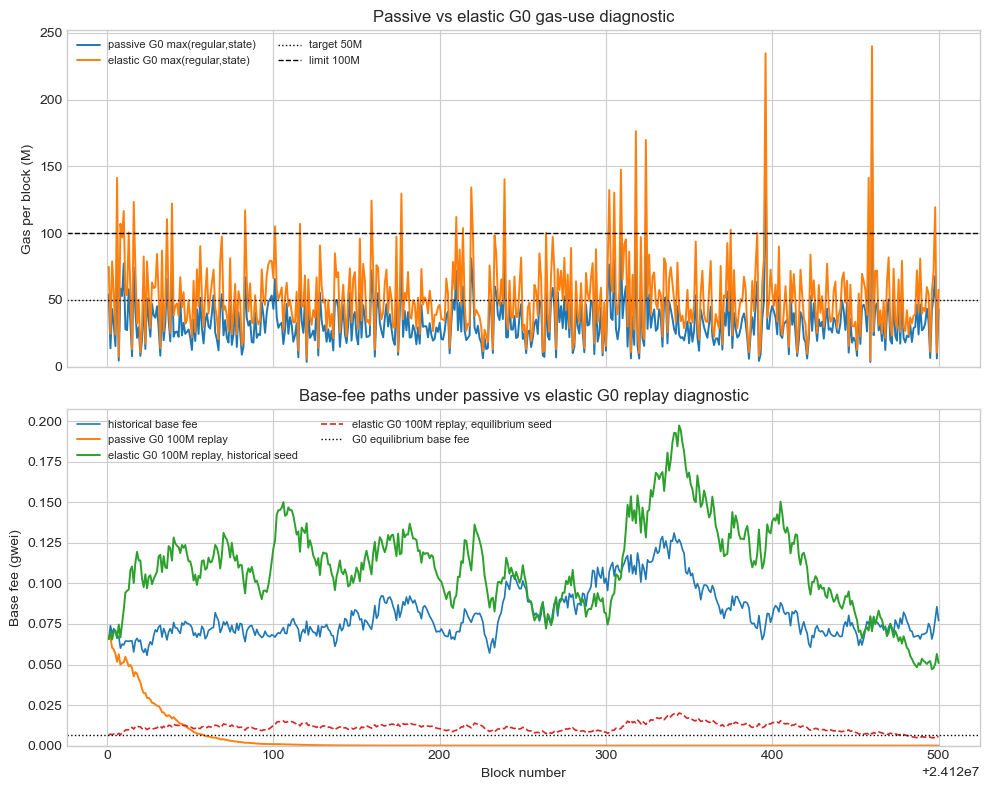

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax = axes[0]
ax.plot(
    elastic_replay["block_number"],
    elastic_replay["g0_passive_basefee_input_gas"] / 1e6,
    label="passive G0 max(regular,state)",
    linewidth=1.4,
)
ax.plot(
    elastic_replay["block_number"],
    elastic_replay["g0_elastic_basefee_input_gas"] / 1e6,
    label="elastic G0 max(regular,state)",
    linewidth=1.4,
)
ax.axhline(CENTRAL_GAS_TARGET / 1e6, color="black", linestyle=":", linewidth=1, label="target 50M")
ax.axhline(CENTRAL_GAS_LIMIT / 1e6, color="black", linestyle="--", linewidth=1, label="limit 100M")
ax.set_ylabel("Gas per block (M)")
ax.set_ylim(bottom=0)
ax.set_title("Passive vs elastic G0 gas-use diagnostic")
ax.legend(ncols=2, fontsize=8)

ax = axes[1]
ax.plot(
    elastic_replay["block_number"],
    elastic_replay["base_fee_per_gas"] / 1e9,
    label="historical base fee",
    linewidth=1.2,
)
ax.plot(
    elastic_replay["block_number"],
    elastic_replay["g0_passive_100m_base_fee"] / 1e9,
    label="passive G0 100M replay",
    linewidth=1.4,
)
ax.plot(
    elastic_replay["block_number"],
    elastic_replay["g0_elastic_100m_base_fee"] / 1e9,
    label="elastic G0 100M replay, historical seed",
    linewidth=1.4,
)
ax.plot(
    elastic_replay["block_number"],
    elastic_replay["g0_elastic_100m_base_fee_seeded_at_equilibrium"] / 1e9,
    label="elastic G0 100M replay, equilibrium seed",
    linewidth=1.2,
    linestyle="--",
)
ax.axhline(
    equilibrium_seed_base_fee / 1e9,
    color="black",
    linestyle=":",
    linewidth=1,
    label="G0 equilibrium base fee",
)
ax.set_ylabel("Base fee (gwei)")
ax.set_xlabel("Block number")
ax.set_ylim(bottom=0)
ax.set_title("Base-fee paths under passive vs elastic G0 replay diagnostic")
ax.legend(ncols=2, fontsize=8)

fig.tight_layout()
fig.savefig(PLOTS_DIR / f"g0_elastic_replay_diagnostic_{BLOCK_LABEL}.png", dpi=160)
plt.show()

## Eta-Data Sweep

This sweep shows how the recovered G0-local data and execution elasticities move as the data-vs-execution substitution prior changes.

Only the data/execution split changes materially here; the top-level state/rest parameters are held fixed.

In [11]:
sweep = results[
    (results["gas_limit"] == 100_000_000)
    & (results["share_mode"] == "maria_own_price")
].copy()
sweep.to_csv(OUT_SWEEP_CSV, index=False)

sweep[[
    "eta_data",
    "alpha_data_given_rest_G0_physical",
    "epsilon_rest_G0",
    "epsilon_data",
    "epsilon_execution",
    "data_physical_gas_M",
    "execution_physical_gas_M",
    "valid_nonnegative_execution",
]]

,eta_data,alpha_data_given_rest_G0_physical,epsilon_rest_G0,epsilon_data,epsilon_execution,data_physical_gas_M,execution_physical_gas_M,valid_nonnegative_execution
0,0.000000,0.041984,0.086770,0.086770,0.086770,1.400105,31.948510,True
1,0.100000,0.039554,0.086770,0.182815,0.082815,1.319088,32.029527,True
2,0.300000,0.035094,0.086770,0.376242,0.076242,1.170340,32.178275,True
3,0.429418,0.032470,0.086770,0.502244,0.072827,1.082843,32.265772,True
4,0.600000,0.029300,0.086770,0.669190,0.069190,0.977127,32.371488,True
5,1.000000,0.023000,0.086770,1.063770,0.063770,0.767030,32.581585,True


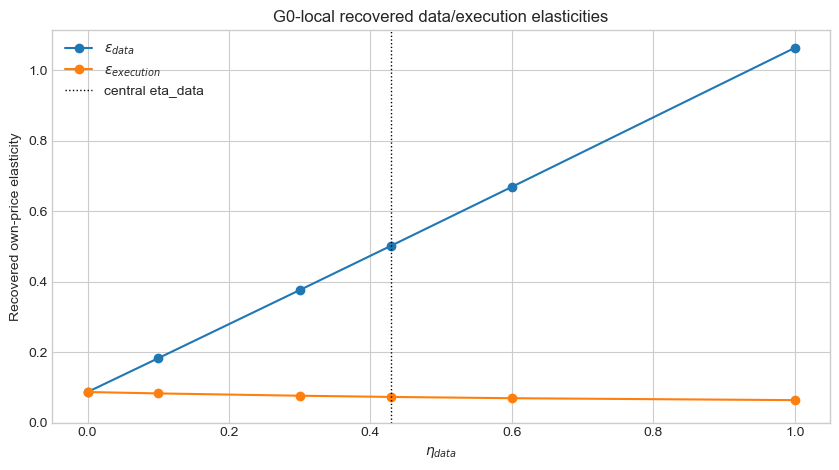

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(sweep["eta_data"], sweep["epsilon_data"], marker="o", label=r"$\epsilon_{data}$")
ax.plot(sweep["eta_data"], sweep["epsilon_execution"], marker="o", label=r"$\epsilon_{execution}$")
ax.axvline(ETA_DATA_CENTRAL, color="black", linestyle=":", linewidth=1, label="central eta_data")
ax.set_xlabel(r"$\eta_{data}$")
ax.set_ylabel("Recovered own-price elasticity")
ax.set_title("G0-local recovered data/execution elasticities")
ax.set_ylim(bottom=0)
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"g0_eta_data_elasticity_sweep_{BLOCK_LABEL}.png", dpi=160)
plt.show()

## Passive vs Elastic G0 Resource Use

This plot compares:

- observed H0 gas decomposition;
- passive G0 repricing of the same 500 blocks;
- central elastic G0 equilibrium at the 100M limit.

Again, BAL is excluded from G0 gas. BAL will enter as priced bandwidth only in Mechanism A/B.

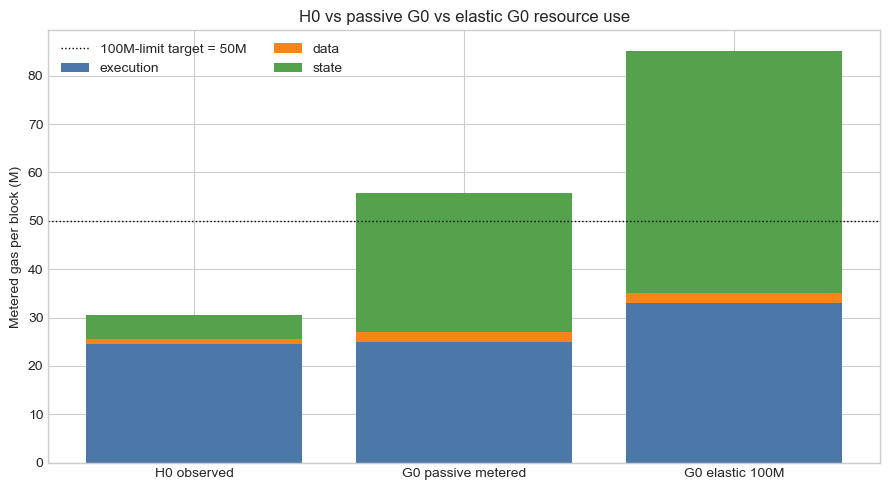

,execution,data,state
case,,,
H0 observed,24.462873,1.072056,4.935713
G0 passive metered,25.042216,2.042926,28.665593
G0 elastic 100M,33.029908,2.063481,50.000000


In [13]:
central_maria = central[central["share_mode"] == "maria_own_price"].iloc[0]
plot_rows = [
    {
        "case": "H0 observed",
        "execution": blocks["h0_execution_gas"].mean() / 1e6,
        "data": blocks["h0_data_gas"].mean() / 1e6,
        "state": blocks["h0_state_gas"].mean() / 1e6,
    },
    {
        "case": "G0 passive metered",
        "execution": blocks["g0_execution_gas"].mean() / 1e6,
        "data": blocks["g0_data_gas"].mean() / 1e6,
        "state": blocks["g0_state_gas"].mean() / 1e6,
    },
    {
        "case": "G0 elastic 100M",
        "execution": central_maria["execution_metered_gas_M"],
        "data": central_maria["data_metered_gas_M"],
        "state": central_maria["state_metered_gas_M"],
    },
]
plot_df = pd.DataFrame(plot_rows).set_index("case")

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(plot_df))
colors = {"execution": "#4C78A8", "data": "#F58518", "state": "#54A24B"}
for col in ["execution", "data", "state"]:
    ax.bar(plot_df.index, plot_df[col], bottom=bottom, label=col, color=colors[col])
    bottom += plot_df[col].values
ax.axhline(50, color="black", linestyle=":", linewidth=1, label="100M-limit target = 50M")
ax.set_ylabel("Metered gas per block (M)")
ax.set_title("H0 vs passive G0 vs elastic G0 resource use")
ax.legend(ncols=2)
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"g0_resource_use_{BLOCK_LABEL}.png", dpi=160)
plt.show()

plot_df

## Outputs

This notebook writes:

- `data/g0_reference_decomposition_24120001_24120500.csv`
- `data/g0_elastic_reference_results_24120001_24120500.csv`
- `data/g0_equilibrium_base_fee_model_24120001_24120500.csv`
- `data/g0_eta_data_sweep_24120001_24120500.csv`
- `data/g0_elastic_replay_diagnostic_24120001_24120500.csv`
- `plots/g0_equilibrium_base_fee_model_24120001_24120500.png`
- `plots/g0_eta_data_elasticity_sweep_24120001_24120500.png`
- `plots/g0_elastic_replay_diagnostic_24120001_24120500.png`
- `plots/g0_resource_use_24120001_24120500.png`

The main row to carry forward into Mechanism A/B is the 100M-limit central `eta_data` row using Maria's effective-price interpretation.


### BAL Diagnostic

BAL bytes are present in the historical payload, but they are not priced in G0.
The table below records their size only as a diagnostic. G0 gas remains execution + data folded into regular gas + EIP-8037 state gas.

In [14]:
bal_diagnostic = pd.DataFrame([{
    "mean_bal_rlp_bytes_per_block": blocks["bal_rlp_bytes"].mean(),
    "p95_bal_rlp_bytes_per_block": blocks["bal_rlp_bytes"].quantile(0.95),
    "max_bal_rlp_bytes_per_block": blocks["bal_rlp_bytes"].max(),
    "g0_bal_gas": 0,
    "note": "BAL is payload diagnostic only in G0; it is priced in Mechanism A/B bandwidth.",
}])
bal_diagnostic

,mean_bal_rlp_bytes_per_block,p95_bal_rlp_bytes_per_block,max_bal_rlp_bytes_per_block,g0_bal_gas,note
0,"148,168.182000","295,901.050000",363031,0,BAL is payload diagnostic only in G0; it is pr...
